In [6]:
from datasets import load_dataset

raw_dataset = load_dataset("json", data_files={
    "train": "data/train_dialogue.json",
    "validation": "data/validation_dialogue.json",
    "test": "data/test_dialogue.json",
})

In [7]:
from transformers import AutoTokenizer
model_checkpoint = "bert-base-chinese"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [32]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)


tokenized_dataset = raw_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["text", "label_name"],  # 只删字符串列
)

In [23]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [24]:
from transformers import AutoModelForSequenceClassification

id2label = {0: "伤心", 1: "关心", 2: "厌恶", 3: "平静", 4: "惊讶", 5: "开心", 6: "生气", 7: "疑问"}
label2id = {v: k for k, v in id2label.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-chinese", num_labels=8,
    id2label=id2label, label2id=label2id
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
from transformers import TrainingArguments
args = TrainingArguments(
    "emotion-classification",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=True,
)

In [26]:
import numpy as np
from evaluate import load

metric_accuracy = load("accuracy")
metric_f1 = load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_accuracy.compute(predictions=preds, references=labels)
    f1 = metric_f1.compute(predictions=preds, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

In [27]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

C:\Users\27729\AppData\Local\Temp\ipykernel_20916\4091371544.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [34]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

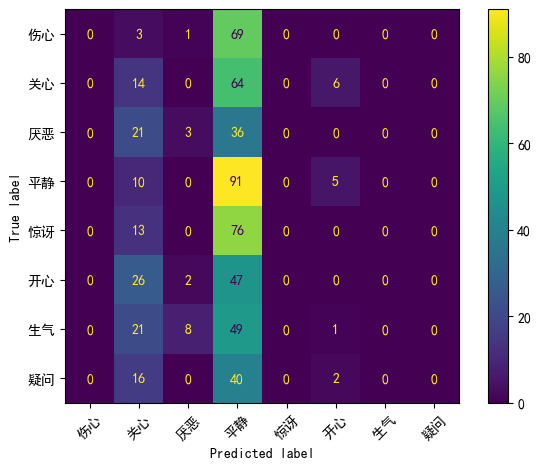

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 获取预测结果
preds_output = trainer.predict(tokenized_dataset["validation"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# 0-7 对应: 伤心/关心/厌恶/平静/惊讶/开心/生气/疑问
display = ["伤心", "关心", "厌恶", "平静", "惊讶", "开心", "生气", "疑问"]

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=display,
    xticks_rotation=45,
)
plt.tight_layout()


In [36]:
pre_train_metrics = trainer.evaluate()
print(pre_train_metrics)

{'eval_loss': 2.1116294860839844, 'eval_model_preparation_time': 0.0019, 'eval_accuracy': 0.17307692307692307, 'eval_f1': 0.06632191980375371, 'eval_runtime': 3.1781, 'eval_samples_per_second': 196.342, 'eval_steps_per_second': 24.543}


In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy,F1
1,No log,0.483477,0.001900,0.850962,0.845686
2,0.734000,0.486492,0.001900,0.863782,0.860366
3,0.232300,0.478193,0.001900,0.883013,0.881376


TrainOutput(global_step=1092, training_loss=0.4528856443398165, metrics={'train_runtime': 142.4589, 'train_samples_per_second': 61.302, 'train_steps_per_second': 7.665, 'total_flos': 160796238922176.0, 'train_loss': 0.4528856443398165, 'epoch': 3.0})

              precision    recall  f1-score   support

          伤心      0.918     0.918     0.918        73
          关心      0.865     0.917     0.890        84
          厌恶      0.814     0.934     0.870        61
          平静      0.888     0.829     0.857       105
          惊讶      0.952     0.888     0.919        89
          开心      0.838     0.827     0.832        75
          生气      0.890     0.823     0.855        79
          疑问      0.781     0.862     0.820        58

    accuracy                          0.872       624
   macro avg      0.868     0.875     0.870       624
weighted avg      0.875     0.872     0.872       624



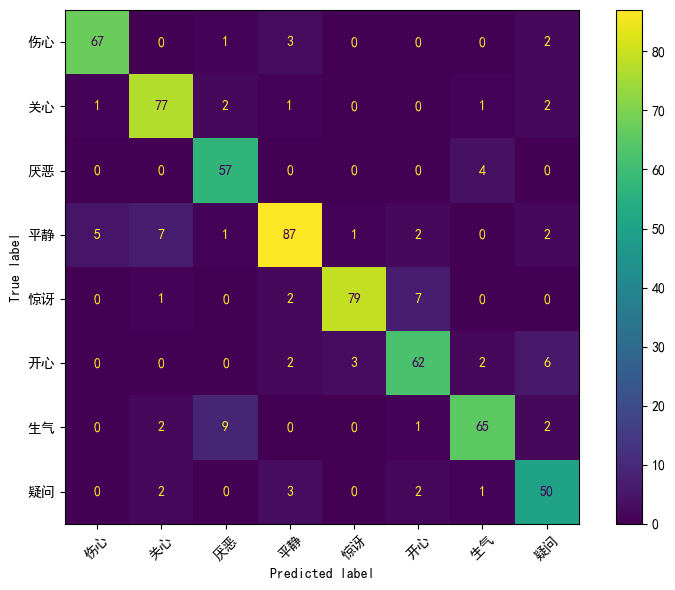

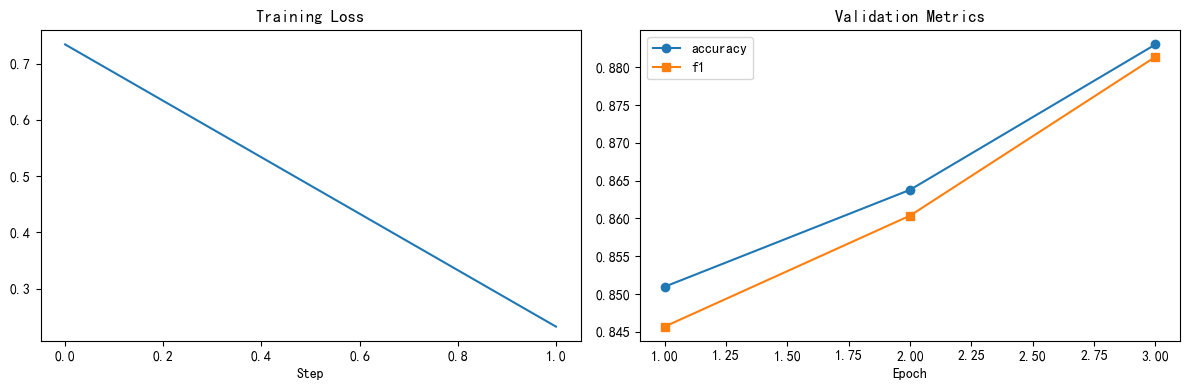

In [38]:
from sklearn.metrics import classification_report

display = ["伤心", "关心", "厌恶", "平静", "惊讶", "开心", "生气", "疑问"]

# 1. 测试集评估（混淆矩阵）
preds_output = trainer.predict(tokenized_dataset["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=display,
    xticks_rotation=45,
    ax=ax
)
plt.tight_layout()

# 2. 分类报告（每类 precision/recall/f1）
print(classification_report(
    y_true, y_pred,
    target_names=display,
    digits=3
))


# 3. 训练曲线（损失 + 评估指标）
import pandas as pd

history = trainer.state.log_history
train_loss = [h["loss"] for h in history if "loss" in h]
val_metrics = [h for h in history if "eval_loss" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_loss, label="train loss")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Step")

if val_metrics:
    epochs = range(1, len(val_metrics) + 1)
    axes[1].plot(epochs, [m["eval_accuracy"] for m in val_metrics], "o-", label="accuracy")
    axes[1].plot(epochs, [m["eval_f1"] for m in val_metrics], "s-", label="f1")
    axes[1].set_title("Validation Metrics"); axes[1].set_xlabel("Epoch")
    axes[1].legend()
plt.tight_layout()

In [39]:
from transformers import pipeline
text_classifier = pipeline(
    "text-classification", model="./emotion-classification"
)
text_classifier("曾经最好的朋友，现在连点赞都不会了。")

Device set to use cuda:0


[{'label': '伤心', 'score': 0.9589856266975403}]

In [40]:
text_classifier("清晨，这个转折来得太突然，我一脸懵逼，但又无能为力。")

[{'label': '伤心', 'score': 0.6730613708496094}]

In [41]:
text_classifier("你在我最无助的时候给了我依靠！")

[{'label': '生气', 'score': 0.8813921213150024}]

In [42]:
text_classifier("我懒得理你。")

[{'label': '厌恶', 'score': 0.3765483796596527}]

In [43]:
text_classifier("傻逼，你妈死了")

[{'label': '生气', 'score': 0.7356130480766296}]

In [44]:
text_classifier("田文镜，我操你妈")

[{'label': '生气', 'score': 0.8360768556594849}]

In [48]:
model_raw = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-chinese", num_labels=8,
    id2label=id2label, label2id=label2id
)

trainer_raw = Trainer(
    model=model_raw,
    args=TrainingArguments("tmp", report_to="none"),
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("未训练, 评估:", trainer_raw.evaluate())


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\27729\AppData\Local\Temp\ipykernel_20916\161346902.py:6: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_raw = Trainer(


未训练, 评估: {'eval_loss': 2.219078302383423, 'eval_model_preparation_time': 0.002, 'eval_accuracy': 0.1233974358974359, 'eval_f1': 0.04273429273429273, 'eval_runtime': 3.2168, 'eval_samples_per_second': 193.979, 'eval_steps_per_second': 24.247}


In [45]:
# 2. 训练后在训练集和验证集上分别评估
print("训练集:", trainer.evaluate(tokenized_dataset["train"]))
print("验证集:", trainer.evaluate(tokenized_dataset["validation"]))


训练集: {'eval_loss': 0.08985354006290436, 'eval_model_preparation_time': 0.0019, 'eval_accuracy': 0.9762968052215734, 'eval_f1': 0.9758818894380314, 'eval_runtime': 14.3039, 'eval_samples_per_second': 203.511, 'eval_steps_per_second': 25.448, 'epoch': 3.0}
验证集: {'eval_loss': 0.4781932234764099, 'eval_model_preparation_time': 0.0019, 'eval_accuracy': 0.8830128205128205, 'eval_f1': 0.881376279087038, 'eval_runtime': 3.0836, 'eval_samples_per_second': 202.364, 'eval_steps_per_second': 25.295, 'epoch': 3.0}


In [49]:
trainer.evaluate(tokenized_dataset["test"])


{'eval_loss': 0.4978993833065033,
 'eval_model_preparation_time': 0.0019,
 'eval_accuracy': 0.8717948717948718,
 'eval_f1': 0.8701385249581114,
 'eval_runtime': 3.289,
 'eval_samples_per_second': 189.725,
 'eval_steps_per_second': 23.716,
 'epoch': 3.0}

In [50]:
trainer.push_to_hub(commit_message="Training complete", tags="summarization")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Kate-lf/emotion-classification/commit/ede10fe7c87179ef00c5e0e6a9b6d76882d0f2f3', commit_message='Training complete', commit_description='', oid='ede10fe7c87179ef00c5e0e6a9b6d76882d0f2f3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Kate-lf/emotion-classification', endpoint='https://huggingface.co', repo_type='model', repo_id='Kate-lf/emotion-classification'), pr_revision=None, pr_num=None)